# Análise Exploratória — Carteira de Crédito

Este notebook realiza a análise exploratória da carteira de crédito do Lending Club.
O objetivo é compreender a estrutura dos dados, identificar anomalias e extrair
os primeiros sinais de risco antes de qualquer modelagem.

**Etapas:**
1. Carregamento e inspeção inicial
2. Qualidade dos dados — missing, duplicatas e inconsistências
3. Filtragem de contratos maduros
4. Criação de variáveis analíticas
5. Análise exploratória: distribuições, risco por segmento, correlações
6. Conclusões e exportação

### Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, mannwhitneyu

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 1. Carregamento e Estrutura do Dataset

In [2]:
COLS = [
    'loan_amnt',
    'loan_status',
    'grade',
    'fico_range_low',
    'fico_range_high',
    'int_rate',
    'term'
]

df_raw = pd.read_csv(
    '../data/raw/loan_default.csv',
    usecols=COLS,
    low_memory=False
)

print(f'Shape bruto: {df_raw.shape}')
df_raw.head()

Shape bruto: (2260701, 7)


,loan_amnt,term,int_rate,grade,loan_status,fico_range_low,fico_range_high
0,3600.0000,36 months,13.9900,C,Fully Paid,675.0000,679.0000
1,24700.0000,36 months,11.9900,C,Fully Paid,715.0000,719.0000
2,20000.0000,60 months,10.7800,B,Fully Paid,695.0000,699.0000
3,35000.0000,60 months,14.8500,C,Current,785.0000,789.0000
4,10400.0000,60 months,22.4500,F,Fully Paid,695.0000,699.0000


### 2. Qualidade dos Dados

Antes de qualquer análise é necessário verificar a integridade dos dados.
Problemas de qualidade não detectados contaminam todas as métricas subsequentes.

In [3]:
# --- 2.1 Valores ausentes ---
missing = df_raw.isnull().mean().sort_values(ascending=False) * 100
print('Percentual de valores ausentes por coluna:')
print(missing[missing > 0].to_string() if (missing > 0).any() else 'Nenhum valor ausente.')

Percentual de valores ausentes por coluna:
loan_amnt         0.0015
term              0.0015
int_rate          0.0015
grade             0.0015
loan_status       0.0015
fico_range_low    0.0015
fico_range_high   0.0015


In [4]:
# --- 2.2 Investigação de duplicatas ---
# 59% dos registros brutos são duplicatas — isso é anômalo e merece investigação.
# O dataset Lending Club é distribuído como arquivo CSV acumulado; versões diferentes
# do dataset incluem registros históricos que se repetem entre releases.
# Como não temos chave de contrato única, toda combinação idêntica de atributos
# é tratada como registro duplicado.

n_total = len(df_raw)
n_duplicates = df_raw.duplicated().sum()
n_unique = n_total - n_duplicates

print(f'Registros totais   : {n_total:,}')
print(f'Registros únicos   : {n_unique:,}')
print(f'Duplicatas         : {n_duplicates:,} ({n_duplicates/n_total:.1%} do total)')
print()

# Verificar se duplicatas se concentram em algum status de empréstimo
dup_mask = df_raw.duplicated(keep=False)
print('Distribuição de loan_status nas duplicatas:')
print(df_raw[dup_mask]['loan_status'].value_counts(normalize=True).head(10))
print()
print('Distribuição de loan_status no dataset completo:')
print(df_raw['loan_status'].value_counts(normalize=True).head(10))

Registros totais   : 2,260,701
Registros únicos   : 928,764
Duplicatas         : 1,331,937 (58.9% do total)

Distribuição de loan_status nas duplicatas:
loan_status
Fully Paid                                            0.4809
Current                                               0.4288
Charged Off                                           0.0864
Late (31-120 days)                                    0.0031
In Grace Period                                       0.0006
Late (16-30 days)                                     0.0002
Does not meet the credit policy. Status:Fully Paid    0.0001
Does not meet the credit policy. Status:Charged Off   0.0000
Name: proportion, dtype: float64

Distribuição de loan_status no dataset completo:
loan_status
Fully Paid                                            0.4763
Current                                               0.3885
Charged Off                                           0.1188
Late (31-120 days)                                    0.0095
In Grace

In [5]:
# --- 2.3 Verificar se duplicatas são concentradas em alguma grade ---
print('Distribuição de grade nas duplicatas vs total:')
dup_grade = df_raw[dup_mask]['grade'].value_counts(normalize=True)
all_grade = df_raw['grade'].value_counts(normalize=True)
comparison = pd.DataFrame({'duplicatas': dup_grade, 'total': all_grade})
comparison['diferenca_pp'] = (comparison['duplicatas'] - comparison['total']) * 100
print(comparison)
print()
print('Conclusão: se a diferença em pp for pequena, as duplicatas são distribuídas'
      ' uniformemente e não introduzem viés sistemático.')

Distribuição de grade nas duplicatas vs total:
       duplicatas  total  diferenca_pp
grade                                 
B          0.3203 0.2935        2.6795
C          0.2978 0.2875        1.0293
A          0.2120 0.1915        2.0460
D          0.1258 0.1435       -1.7726
E          0.0349 0.0600       -2.5136
F          0.0077 0.0185       -1.0760
G          0.0015 0.0054       -0.3926

Conclusão: se a diferença em pp for pequena, as duplicatas são distribuídas uniformemente e não introduzem viés sistemático.


In [6]:
# Remover duplicatas após investigação
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f'Shape após remoção de duplicatas: {df.shape}')

Shape após remoção de duplicatas: (928764, 7)


### 3. Filtragem de Contratos Maduros

Para modelar risco de crédito com precisão, utilizamos apenas contratos com
desfecho definido (Fully Paid ou Charged Off/Default).
Contratos *Current* ou *In Grace Period* têm PD desconhecida e contaminam
a estimativa da taxa de default.

In [7]:
print('Distribuição de loan_status antes da filtragem:')
print(df['loan_status'].value_counts())
print()

Distribuição de loan_status antes da filtragem:
loan_status
Fully Paid                                             432296
Current                                                297348
Charged Off                                            165653
Late (31-120 days)                                      18613
In Grace Period                                          7923
Late (16-30 days)                                        4212
Does not meet the credit policy. Status:Fully Paid       1924
Does not meet the credit policy. Status:Charged Off       754
Default                                                    40
Name: count, dtype: int64



In [8]:
MATURE_STATUSES = ['Fully Paid', 'Charged Off', 'Default']

df = df[df['loan_status'].isin(MATURE_STATUSES)].copy()
print(f'Shape após filtro de contratos maduros: {df.shape}')

Shape após filtro de contratos maduros: (597989, 7)


### 4. Criação de Variáveis Analíticas

In [9]:
# Variável alvo: default binário
df['default'] = df['loan_status'].isin(['Charged Off', 'Default']).astype('int8')
df.drop(columns=['loan_status'], inplace=True)

# Score médio FICO (média de low e high é a proxy padrão usada em modelos de crédito)
df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2

# EAD: valor do empréstimo como proxy de exposição
# Em modelos reais o EAD considera saldo devedor + compromissos não utilizados.
# Aqui usamos loan_amnt como simplificação razoável para dados históricos.
df['EAD'] = df['loan_amnt']

# Limpeza da taxa de juros
df['int_rate'] = (
    df['int_rate']
    .astype(str)
    .str.replace('%', '', regex=False)
    .astype(float)
)

print('Variáveis criadas:')
df[['default', 'fico_score', 'EAD', 'int_rate']].describe()

Variáveis criadas:


,default,fico_score,EAD,int_rate
count,597989.0000,597989.0000,597989.0000,597989.0000
mean,0.2771,702.2426,14879.8410,14.5620
std,0.4476,34.4295,8956.3829,5.2312
min,0.0000,627.0000,500.0000,5.3100
25%,0.0000,677.0000,7700.0000,10.7500
50%,0.0000,692.0000,13475.0000,13.9900
75%,1.0000,722.0000,20700.0000,17.9700
max,1.0000,847.5000,40000.0000,30.9900


### 5. Análise Exploratória

In [10]:
# --- 5.1 Estrutura geral da carteira ---
default_rate = df['default'].mean()
print('=== Estrutura da Carteira ===')
print(f'Contratos         : {len(df):,}')
print(f'Exposição total   : R$ {df["EAD"].sum():,.0f}')
print(f'Ticket médio      : R$ {df["EAD"].mean():,.0f}')
print(f'Taxa de default   : {default_rate:.2%}')
print(f'FICO mínimo       : {df["fico_score"].min()}')
print(f'FICO máximo       : {df["fico_score"].max()}')

=== Estrutura da Carteira ===
Contratos         : 597,989
Exposição total   : R$ 8,897,981,225
Ticket médio      : R$ 14,880
Taxa de default   : 27.71%
FICO mínimo       : 627.0
FICO máximo       : 847.5


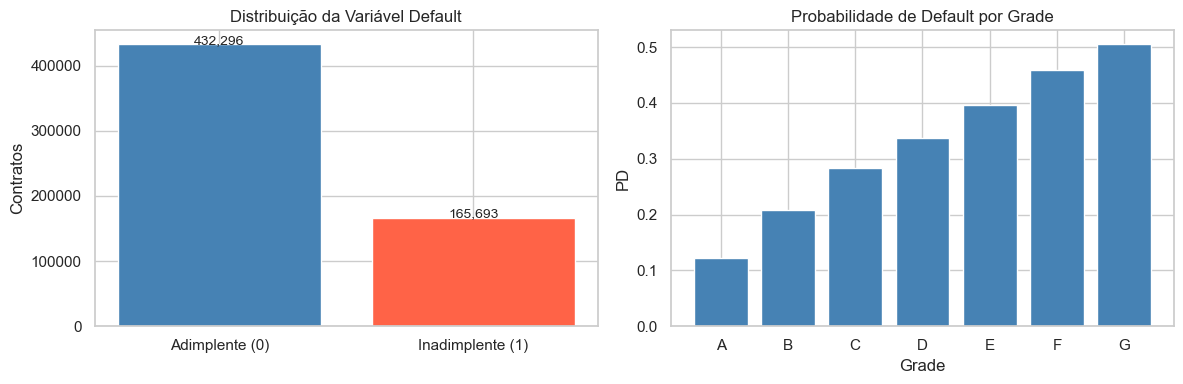

Monotonicidade PD por grade:
          pd  volume
grade               
A     0.1223   82339
B     0.2079  139068
C     0.2829  162000
D     0.3365  112241
E     0.3968   68320
F     0.4594   25950
G     0.5045    8071


In [11]:
# --- 5.2 Distribuição da variável alvo ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['default'].value_counts()
axes[0].bar(['Adimplente (0)', 'Inadimplente (1)'], counts.values,
            color=['steelblue', 'tomato'])
axes[0].set_title('Distribuição da Variável Default')
axes[0].set_ylabel('Contratos')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# PD por grade
pd_grade = (
    df.groupby('grade', observed=True)
    .agg(pd=('default', 'mean'), volume=('default', 'count'))
    .sort_index()
)
axes[1].bar(pd_grade.index, pd_grade['pd'], color='steelblue')
axes[1].set_title('Probabilidade de Default por Grade')
axes[1].set_ylabel('PD')
axes[1].set_xlabel('Grade')

plt.tight_layout()
plt.savefig('../images/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Monotonicidade PD por grade:')
print(pd_grade)

C:\Users\letic\AppData\Local\Temp\ipykernel_16140\1870554258.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='fico_score', data=df, ax=axes[1],
C:\Users\letic\AppData\Local\Temp\ipykernel_16140\1870554258.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Adimplente', 'Inadimplente'])


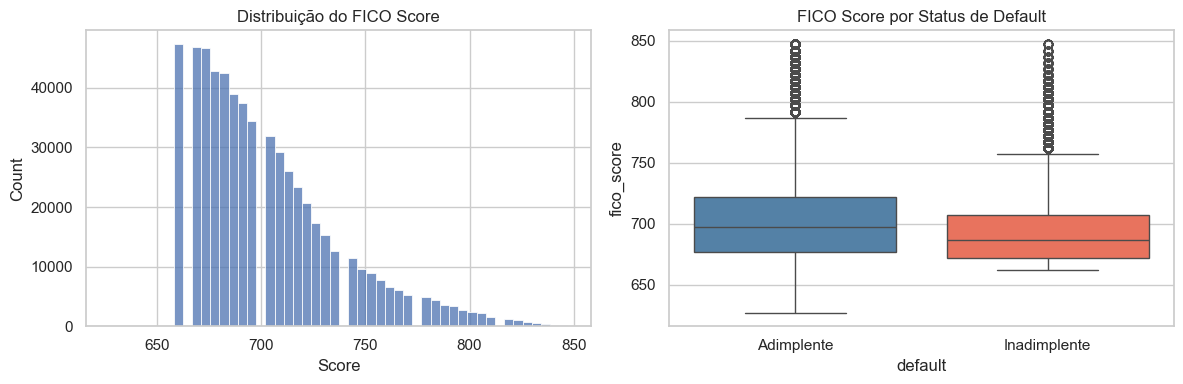


Estatísticas de FICO por status:
              count     mean     std      min      25%      50%      75%  \
default                                                                    
0       432296.0000 705.3676 35.9326 627.0000 677.0000 697.0000 722.0000   
1       165693.0000 694.0895 28.5921 662.0000 672.0000 687.0000 707.0000   

             max  
default           
0       847.5000  
1       847.5000  


In [12]:
# --- 5.3 Distribuição do FICO Score ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['fico_score'], bins=50, ax=axes[0])
axes[0].set_title('Distribuição do FICO Score')
axes[0].set_xlabel('Score')

# Score por status de default
sns.boxplot(x='default', y='fico_score', data=df, ax=axes[1],
            palette=['steelblue', 'tomato'])
axes[1].set_title('FICO Score por Status de Default')
axes[1].set_xticklabels(['Adimplente', 'Inadimplente'])

plt.tight_layout()
plt.show()

print('\nEstatísticas de FICO por status:')
print(df.groupby('default')['fico_score'].describe())

In [13]:
# --- 5.4 Teste estatístico: diferença de score entre grupos ---
# Usamos Mann-Whitney U (não paramétrico) pois a distribuição pode não ser normal.
# H0: distribuição de score é igual entre adimplentes e inadimplentes

score_adim = df[df['default'] == 0]['fico_score']
score_inadim = df[df['default'] == 1]['fico_score']

stat, p_value = mannwhitneyu(score_adim, score_inadim, alternative='greater')

print('Teste Mann-Whitney U: score adimplentes > score inadimplentes')
print(f'  Estatística U : {stat:,.0f}')
print(f'  P-value       : {p_value:.2e}')
print(f'  Conclusão     : {"Rejeita H0" if p_value < 0.05 else "Não rejeita H0"} — '
      f'score é estatisticamente maior para adimplentes (α=0.05)')

Teste Mann-Whitney U: score adimplentes > score inadimplentes
  Estatística U : 42,266,011,224
  P-value       : 0.00e+00
  Conclusão     : Rejeita H0 — score é estatisticamente maior para adimplentes (α=0.05)


Correlação point-biserial (default vs fico_score): -0.147  p=0.00e+00


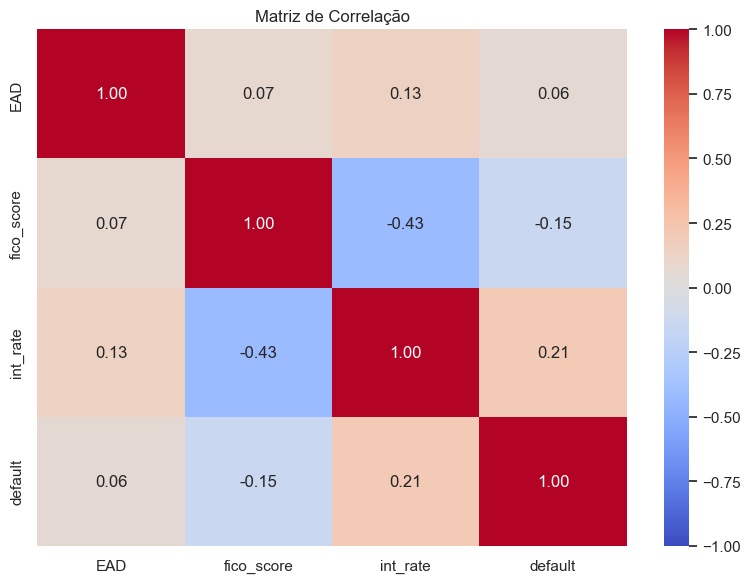

In [14]:
# --- 5.5 Correlação point-biserial e matriz de correlação ---
corr_score, p_corr = pointbiserialr(df['default'], df['fico_score'])
print(f'Correlação point-biserial (default vs fico_score): {corr_score:.3f}  p={p_corr:.2e}')

plt.figure(figsize=(8, 6))
corr_matrix = df[['EAD', 'fico_score', 'int_rate', 'default']].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

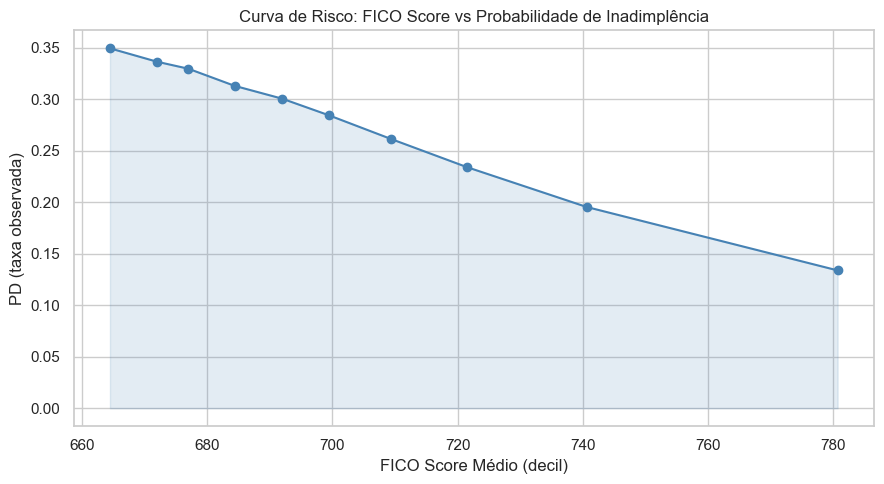


Tabela de risco por decil de score:
 avg_score     pd  volume
  664.4876 0.3493   94112
  672.0000 0.3363   46662
  677.0000 0.3295   42841
  684.3876 0.3129   81477
  692.0000 0.3004   37517
  699.4041 0.2844   66366
  709.3597 0.2613   55367
  721.5138 0.2339   61277
  740.6298 0.1953   57797
  780.6630 0.1338   54573


In [15]:
# --- 5.6 Risk Curve: Score vs PD ---
score_bins = pd.qcut(df['fico_score'], q=10, duplicates='drop')

risk_curve = (
    df.groupby(score_bins, observed=False)
    .agg(
        pd=('default', 'mean'),
        volume=('default', 'count'),
        avg_score=('fico_score', 'mean')
    )
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.plot(risk_curve['avg_score'], risk_curve['pd'], marker='o', color='steelblue')
plt.fill_between(risk_curve['avg_score'], risk_curve['pd'], alpha=0.15, color='steelblue')
plt.title('Curva de Risco: FICO Score vs Probabilidade de Inadimplência')
plt.xlabel('FICO Score Médio (decil)')
plt.ylabel('PD (taxa observada)')
plt.tight_layout()
plt.show()

print('\nTabela de risco por decil de score:')
print(risk_curve[['avg_score', 'pd', 'volume']].to_string(index=False))

In [16]:
# --- 5.7 PD e exposição por prazo ---
term_analysis = (
    df.groupby('term', observed=True)
    .agg(
        pd=('default', 'mean'),
        volume=('default', 'count'),
        exposure=('EAD', 'sum')
    )
)
print('PD e exposição por prazo:')
print(term_analysis)

PD e exposição por prazo:
              pd  volume        exposure
term                                    
36 months 0.2380  410364 5130180975.0000
60 months 0.3625  187625 3767800250.0000


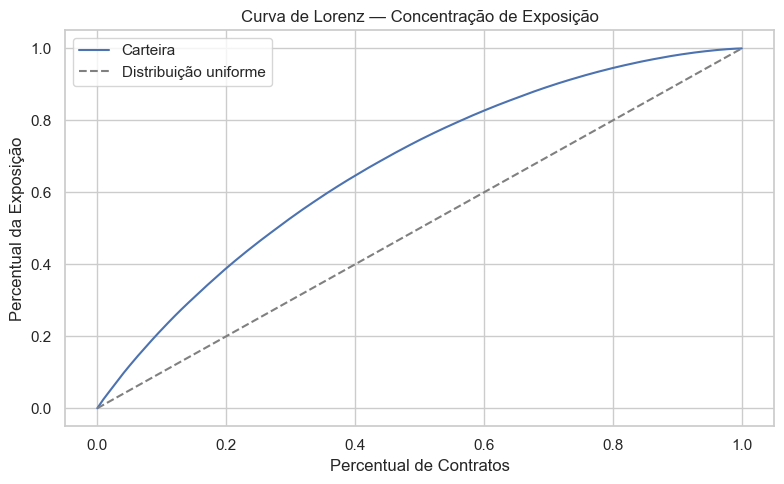

Índice de Gini da exposição (concentração): 0.339
  Próximo de 0 = exposição distribuída uniformemente
  Próximo de 1 = exposição concentrada em poucos contratos


In [17]:
# --- 5.8 Concentração da carteira (Curva de Lorenz) ---
ead_sorted = df.sort_values('EAD', ascending=False)
ead_sorted['cum_exposure_share'] = (
    ead_sorted['EAD'].cumsum() / ead_sorted['EAD'].sum()
)

plt.figure(figsize=(8, 5))
plt.plot(
    np.linspace(0, 1, len(ead_sorted)),
    ead_sorted['cum_exposure_share'].values,
    label='Carteira'
)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Distribuição uniforme')
plt.title('Curva de Lorenz — Concentração de Exposição')
plt.xlabel('Percentual de Contratos')
plt.ylabel('Percentual da Exposição')
plt.legend()
plt.tight_layout()
plt.show()

# Índice de Gini de concentração de EAD
n = len(ead_sorted)
ead_vals = ead_sorted['EAD'].values
gini_ead = 1 - 2 * np.sum(ead_vals[::-1].cumsum()) / (n * ead_vals.sum())
print(f'Índice de Gini da exposição (concentração): {gini_ead:.3f}')
print('  Próximo de 0 = exposição distribuída uniformemente')
print('  Próximo de 1 = exposição concentrada em poucos contratos')

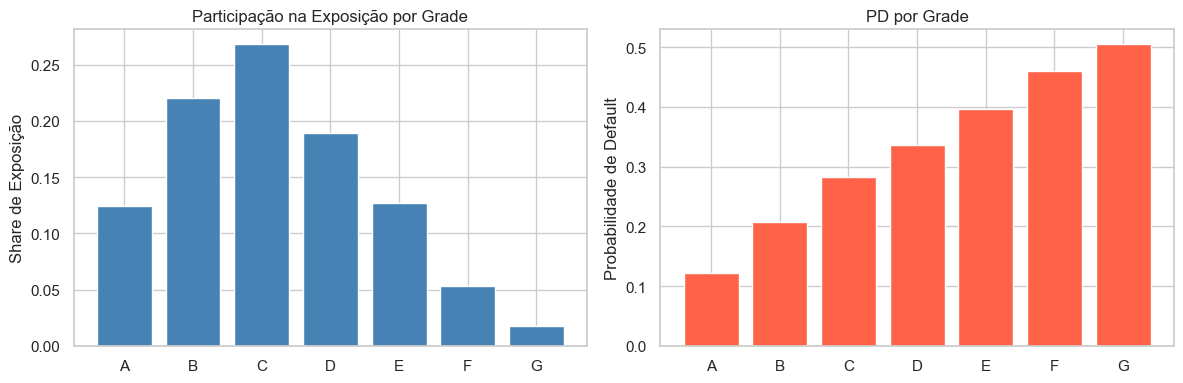

             exposure  contracts  share_exposure
grade                                           
A     1107740375.0000      82339          0.1245
B     1958903350.0000     139068          0.2202
C     2384536250.0000     162000          0.2680
D     1683910275.0000     112241          0.1892
E     1132993575.0000      68320          0.1273
F      470158450.0000      25950          0.0528
G      159738950.0000       8071          0.0180


In [18]:
# --- 5.9 Exposição por grade ---
ead_grade = (
    df.groupby('grade', observed=True)
    .agg(exposure=('EAD', 'sum'), contracts=('EAD', 'count'))
    .sort_index()
)
ead_grade['share_exposure'] = ead_grade['exposure'] / ead_grade['exposure'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(ead_grade.index, ead_grade['share_exposure'], color='steelblue')
axes[0].set_title('Participação na Exposição por Grade')
axes[0].set_ylabel('Share de Exposição')

axes[1].bar(pd_grade.index, pd_grade['pd'], color='tomato')
axes[1].set_title('PD por Grade')
axes[1].set_ylabel('Probabilidade de Default')

plt.tight_layout()
plt.show()
print(ead_grade)

### 6. Conclusões da Análise Exploratória

**Carteira analisada:** ~598 mil contratos maduros com exposição total de ~R$ 8,9 bilhões.

**Principais achados:**

1. **Taxa de default de 27,7%** — elevada, consistente com carteiras de crédito não garantido (unsecured).
2. **Monotonicidade da PD por grade** — a PD aumenta de ~12% (Grade A) até ~50% (Grade G), validando o sistema de rating.
3. **FICO Score** — correlação inversa com default (−0,15). O teste Mann-Whitney confirma que adimplentes têm scores estatisticamente maiores, mas a sobreposição das distribuições reforça que risco é multidimensional.
4. **Concentração de exposição** — a maior parte da carteira está nas grades B e C, que combinam volume e risco moderado.
5. **Prazo:** empréstimos de 60 meses têm PD 36% vs 24% para 36 meses — o prazo é variável relevante.

**Próxima etapa:** Feature Engineering — construção do modelo de PD com regressão logística,
validação estatística e modelagem da LGD por segmento.

In [19]:
# Salvar dataset processado
df.to_parquet('../data/processed/credit_risk_clean.parquet', index=False)
print(f'Dataset salvo: {df.shape}')
print(df.dtypes)

Dataset salvo: (597989, 9)
loan_amnt          float64
term                object
int_rate           float64
grade               object
fico_range_low     float64
fico_range_high    float64
default               int8
fico_score         float64
EAD                float64
dtype: object
